In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/diabetes.csv')
df.columns = df.columns.str.strip()
df.rename(columns={
    'preg': 'Pregnancies', 'plas': 'Glucose', 'pres': 'BloodPressure',
    'Skin': 'SkinThickness', 'test': 'Insulin', 'mass': 'BMI',
    'pedi': 'DiabetesPedigree', 'age': 'Age', 'class': 'Outcome'
}, inplace=True)

df = df.drop_duplicates()

cols_with_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_missing] = df[cols_with_missing].replace(0, np.nan)
for col in cols_with_missing:
    df[col] = df[col].fillna(df[col].median())

X = df.drop('Outcome', axis=1)
y = df['Outcome']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

print("Data ready:", X_train.shape, X_test.shape)

Data ready: (537, 8) (231, 8)


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'Neural Network': MLPClassifier(random_state=42, max_iter=1000)
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} trained.")

Logistic Regression trained.
Decision Tree trained.


C:\Users\Samiya\anaconda3\envs\diabetes-predictor\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM trained.
Neural Network trained.


C:\Users\Samiya\anaconda3\envs\diabetes-predictor\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

results = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    }

results_df = pd.DataFrame(results).T
results_df

,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.744589,0.671875,0.530864,0.593103
Decision Tree,0.688312,0.558442,0.530864,0.544304
SVM,0.744589,0.677419,0.518519,0.587413
Neural Network,0.740260,0.643836,0.580247,0.610390


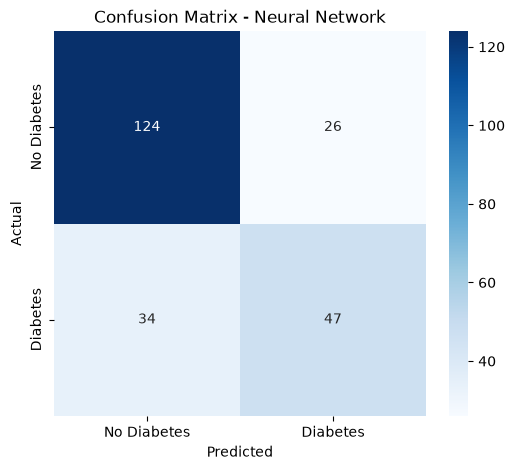

In [9]:
best_name = "Neural Network"

y_pred_best = trained_models[best_name].predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Neural Network')
plt.show()

In [10]:
import joblib

joblib.dump(trained_models['Neural Network'], '../models/diabetes_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print("Model and scaler saved.")

Model and scaler saved.


In [11]:
import json

feature_names = X.columns.tolist()
with open('../models/feature_order.json', 'w') as f:
    json.dump(feature_names, f)

print(feature_names)

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigree', 'Age']


In [2]:
import pandas as pd
import numpy as np
import json
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load and clean
df = pd.read_csv('../data/diabetes.csv')
df.columns = df.columns.str.strip()
df.rename(columns={
    'preg': 'Pregnancies', 'plas': 'Glucose', 'pres': 'BloodPressure',
    'Skin': 'SkinThickness', 'test': 'Insulin', 'mass': 'BMI',
    'pedi': 'DiabetesPedigree', 'age': 'Age', 'class': 'Outcome'
}, inplace=True)
df = df.drop_duplicates()

cols_with_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_missing] = df[cols_with_missing].replace(0, np.nan)
for col in cols_with_missing:
    df[col] = df[col].fillna(df[col].median())

# Now this will work — cols_with_missing and df both exist
medians = {col: df[col].median() for col in cols_with_missing}
with open('../models/medians.json', 'w') as f:
    json.dump(medians, f)

print(medians)

{'Glucose': np.float64(117.0), 'BloodPressure': np.float64(72.0), 'SkinThickness': np.float64(29.0), 'Insulin': np.float64(125.0), 'BMI': np.float64(32.3)}
